In [1]:
pip install tensorflow matplotlib numpy

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

In [4]:
import zipfile
import os

zip_path = '/content/archive.zip'

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content')
    print(f'Successfully extracted {zip_path}')
else:
    print(f'Error: {zip_path} not found. Please ensure the dataset is uploaded.')

Successfully extracted /content/archive.zip


In [5]:
# base directory
base_dir = 'xray_dataset_covid19'

#  image Path
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

# 1. Load the Training Data directly from the 'train' folder
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# 2. Load the Validation/Testing Data directly from the 'test' folder
val_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print(f"Classes found: {class_names}") # Should print ['NORMAL', 'PNEUMONIA']

# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Found 148 files belonging to 2 classes.
Found 40 files belonging to 2 classes.
Classes found: ['NORMAL', 'PNEUMONIA']


In [6]:
model = models.Sequential([
    # Rescale pixels to 0-1
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # Convolutional & Pooling Layers
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Prevent overfitting

    # Final layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
EPOCHS = 10

print("Starting training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Starting training...
Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.4122 - loss: 1.1621 - val_accuracy: 0.5750 - val_loss: 0.6400
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7703 - loss: 0.6130 - val_accuracy: 1.0000 - val_loss: 0.4304
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8108 - loss: 0.4608 - val_accuracy: 1.0000 - val_loss: 0.2308
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8311 - loss: 0.3154 - val_accuracy: 1.0000 - val_loss: 0.0835
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9595 - loss: 0.1424 - val_accuracy: 1.0000 - val_loss: 0.0558
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9324 - loss: 0.1576 - val_accuracy: 1.0000 - val_loss: 0.0385
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9662 - loss: 0.0902 - val_accuracy: 1.0000 - val_loss: 0.0238
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9730 - loss: 0.0643 - val_accuracy: 1.0000

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

--- Prediction Results ---
Image: normal_or_pneumonia1.jpeg
Diagnosis: NORMAL
Confidence: 95.35%


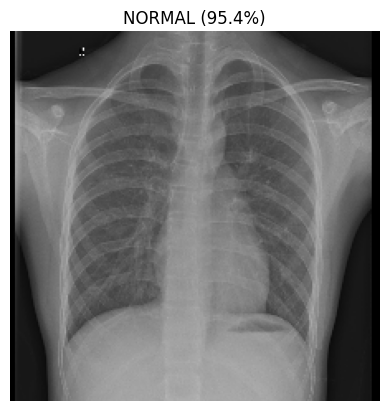

In [13]:
from tensorflow.keras.preprocessing import image

def predict_lung_xray(img_path, trained_model, classes):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Make it a batch of 1

    # Make prediction
    prediction = trained_model.predict(img_array)
    confidence = prediction[0][0]

    # Determine class based on confidence score (threshold 0.5)
    # class_names[1] is typically 'PNEUMONIA', class_names[0] is 'NORMAL'
    if confidence > 0.5:
        predicted_class = classes[1]
        certainty = confidence * 100
    else:
        predicted_class = classes[0]
        certainty = (1 - confidence) * 100

    print(f"\n--- Prediction Results ---")
    print(f"Image: {os.path.basename(img_path)}")
    print(f"Diagnosis: {predicted_class}")
    print(f"Confidence: {certainty:.2f}%")

    # Show the image
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{predicted_class} ({certainty:.1f}%)")
    plt.show()


#  "single prediction" folder
sample_image_path = os.path.join(base_dir, 'single prediction', 'normal_or_pneumonia1.jpeg')


if os.path.exists(sample_image_path):
    predict_lung_xray(sample_image_path, model, class_names)
else:
    print(f"Error: {sample_image_path} not found. Please check the filename.")